In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import YGate
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [2]:
def generate_laplacian_block_encoding(nq, bcs):
    r"""Build the quantum circuit for the block encoding of an N-dimensional Laplacian operator
    
    Args:
        nq (int): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        bcs (list[str]): Boundary conditions of the laplacian. Each item in the list is either "periodic"
            or "dirichlet". The length of the list determines the number of dimensions.
            
    Returns:
        a qiskit.QuantumCircuit object that block encodes the desired Laplacian operator.
    """
    if len(list(filter(lambda x: x != "dirichlet" and x != "periodic", bcs))) != 0:
        raise ValueError("Invalid boundary conditions")
    
    d = len(bcs)
    k = int(np.ceil(np.log2(d)))
    
    # Defining registers
    l_reg = QuantumRegister(2, "l")
    dirichlet_reg = QuantumRegister(1, "dir")
    j_regs = [QuantumRegister(nq, f"j^{{({i})}}") for i in range(d)]
    k_reg = QuantumRegister(k, "k")


    if k == 0:
        qc = QuantumCircuit(*j_regs, dirichlet_reg, l_reg)

        qc.h(l_reg)
        qc.z(l_reg)

        # Apply dirichlet extra gates if BC is Dirichlet
        if bcs[0] == "dirichlet":
            cy0 = YGate().control(nq+2, ctrl_state="0" * (nq + 2))
            cy1 = YGate().control(nq+2, ctrl_state="1" * (nq + 2))

            qc.append(cy0, j_regs[0][:] + l_reg[:] + dirichlet_reg[:])
            qc.append(cy1, j_regs[0][:] + l_reg[:] + dirichlet_reg[:])


        # Apply shift operators
        csu = ShiftUp(nq).control(1, ctrl_state="1")
        csd = ShiftDown(nq).control(1, ctrl_state="0")
        
        qc.append(csd, [l_reg[1]] + j_regs[0][:])
        qc.append(csu, [l_reg[0]] + j_regs[0][:])

        qc.h(l_reg)
        qc.save_unitary()

    else:
        qc = QuantumCircuit(*j_regs, dirichlet_reg, l_reg, k_reg)

        qc.h(k_reg)
        qc.h(l_reg)
        qc.z(l_reg)
        
        for i in range(len(bcs)):
            # Control bitstring for k register
            k_ctrl = bin(i)[2:].zfill(k)

            # Apply dirichlet extra gates if current BC is Dirichlet
            if bcs[i] == "dirichlet":
                cy0 = YGate().control(nq + k + 2, ctrl_state=k_ctrl + "0" * (nq + 2))
                cy1 = YGate().control(nq + k + 2, ctrl_state=k_ctrl + "1" * (nq + 2))

                qc.append(cy0, j_regs[i][:] + l_reg[:] +  k_reg[:] + dirichlet_reg[:])
                qc.append(cy1, j_regs[i][:] + l_reg[:] +  k_reg[:] + dirichlet_reg[:])


            # Apply shift operators
            csu = ShiftUp(nq).control(k + 1, ctrl_state=k_ctrl + "1")
            csd = ShiftDown(nq).control(k + 1, ctrl_state=k_ctrl + "0")

            qc.append(csd, [l_reg[1]] + k_reg[:] + j_regs[i][:])
            qc.append(csu, [l_reg[0]] + k_reg[:] + j_regs[i][:])


        qc.h(l_reg)
        qc.h(k_reg)
        qc.save_unitary()

    return qc

def get_circuit_unitary(qc, nq, d):
    r"""Build the matrix representation of a quantum circuit block encoding a Laplacian.
    
    Args:
        qc (qiskit.QuantumCircuit): The quantum circuit that block encodes a Laplacian.
        nq (int): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        d (int): Laplacian dimension.
    
    Returns:
        a numpy.array representation of the block encoded Laplacian matrix.
    """
    simulator = AerSimulator(method="unitary")
    qc = transpile(qc, simulator)

    result = simulator.run(qc).result()
    unitary = result.get_unitary(qc).data.real
    unitary_subspace = unitary[:2 ** (nq * d), :2 ** (nq * d)]

    return unitary_subspace

def plot_heatmap(nq, bcs, ncs=51, vmax=1.0):
    r"""Plot the matrix elements for a Laplacian operator.
    
    Args:
        nq (int): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        bcs (list[str]): Boundary conditions of the Laplacian.
        ncs (int): Number of colors to use in the plot.
        vmax (float): Color scaling set to -vmax to vmax.
    """
    qc = generate_laplacian_block_encoding(nq, bcs)
    unitary = get_circuit_unitary(qc, nq, len(bcs))
    cmap = plt.get_cmap("seismic", ncs)

    plt.imshow(unitary, cmap=cmap, vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.show()



['periodic']


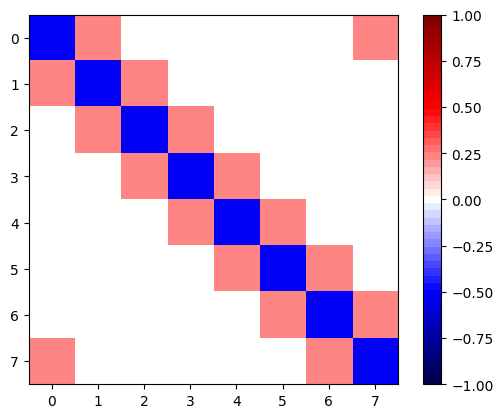

['periodic', 'periodic']


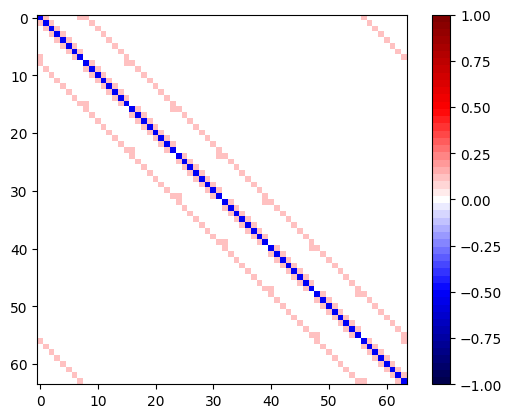

['periodic', 'periodic', 'periodic']


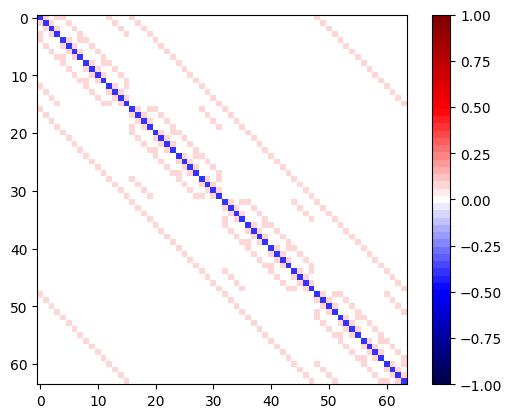

In [3]:
bcs = ["periodic"]
print(bcs)
plot_heatmap(3, bcs)

bcs = ["periodic", "periodic"]
print(bcs)
plot_heatmap(3, bcs)

bcs = ["periodic", "periodic", "periodic"]
print(bcs)
plot_heatmap(2, bcs)

['dirichlet']


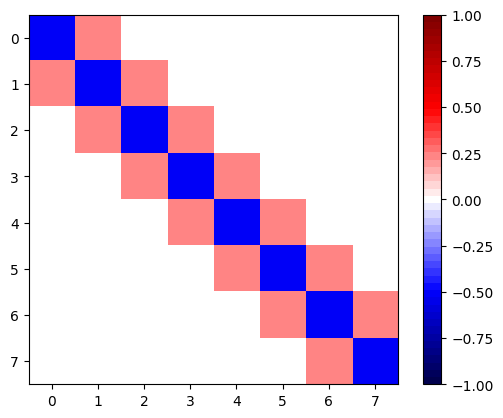

['dirichlet', 'periodic']


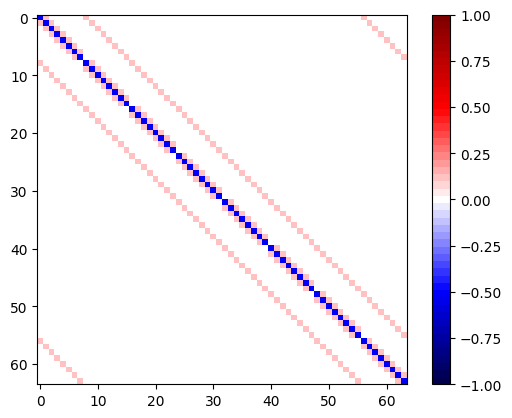

['periodic', 'dirichlet']


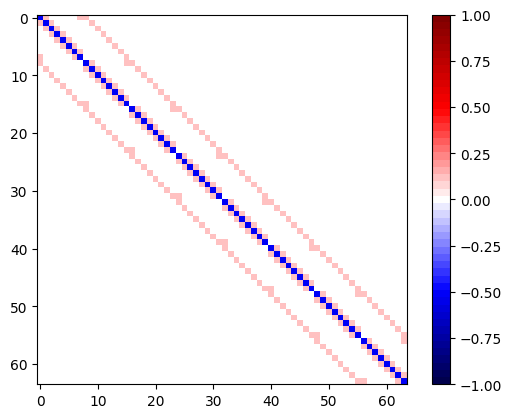

['dirichlet', 'dirichlet']


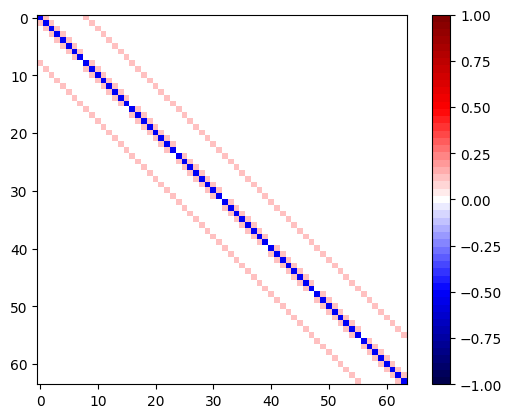

['dirichlet', 'dirichlet', 'dirichlet']


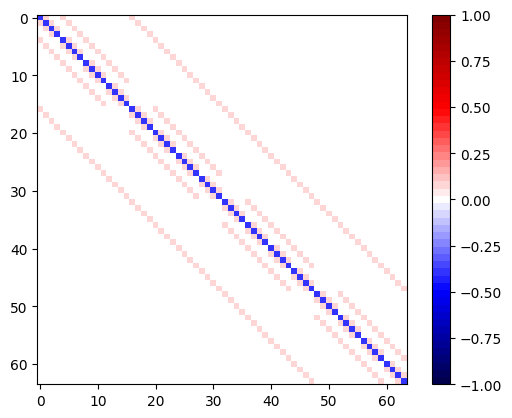

['periodic', 'dirichlet', 'periodic']


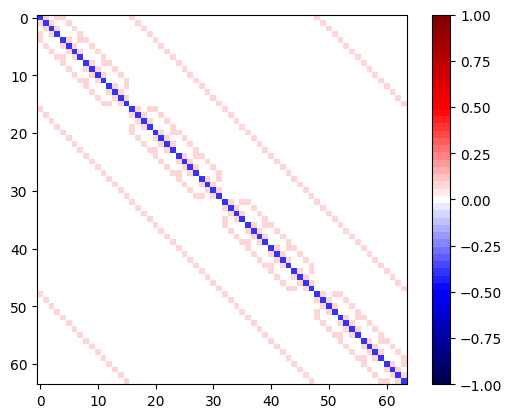

['dirichlet', 'periodic', 'dirichlet']


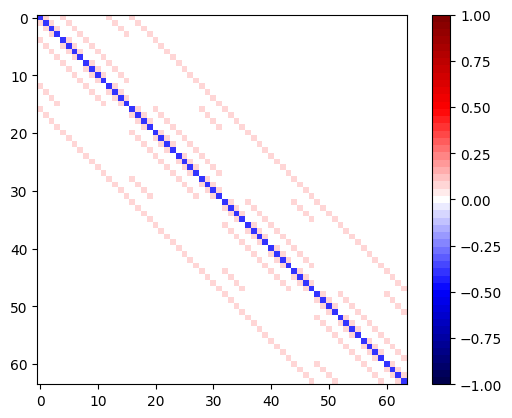

In [4]:
bcs = ["dirichlet"]
print(bcs)
plot_heatmap(3, bcs)

bcs = ["dirichlet", "periodic"]
print(bcs)
plot_heatmap(3, bcs)

bcs = ["periodic", "dirichlet"]
print(bcs)
plot_heatmap(3, bcs)

bcs = ["dirichlet", "dirichlet"]
print(bcs)
plot_heatmap(3, bcs)

bcs = ["dirichlet", "dirichlet", "dirichlet"]
print(bcs)
plot_heatmap(2, bcs)

bcs = ["periodic", "dirichlet", "periodic"]
print(bcs)
plot_heatmap(2, bcs)

bcs = ["dirichlet", "periodic", "dirichlet"]
print(bcs)
plot_heatmap(2, bcs)